In [6]:
from google.colab import files
uploaded = files.upload()


Saving student-mat.csv to student-mat.csv


In [7]:
df = pd.read_csv("student-mat.csv", sep=";")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [9]:
def grade_category(g):
    if g < 10:
        return "Fail"
    elif g <= 12:
        return "C"
    elif g <= 15:
        return "B"
    else:
        return "A"

df["Grade_Category"] = df["G3"].apply(grade_category)

In [10]:
df[["G3","Grade_Category"]].head()

,G3,Grade_Category
0,6,Fail
1,6,Fail
2,10,C
3,15,B
4,10,C


In [12]:
X = df.drop(["G1","G2","G3","Grade_Category"], axis=1)
y = df["Grade_Category"]

In [13]:
X.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,yes,no,no,4,3,4,1,1,3,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,yes,no,5,3,3,1,1,3,4
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,yes,no,4,3,2,2,3,3,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,yes,3,2,2,1,1,5,2
4,GP,F,16,U,GT3,T,3,3,other,other,...,yes,no,no,4,3,2,1,2,5,4


In [14]:
y.head()

,Grade_Category
0,Fail
1,Fail
2,C
3,B
4,C


In [15]:
X.shape
y.shape

(395,)

In [16]:
X = pd.get_dummies(X)

In [17]:
X.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,activities_no,activities_yes,nursery_no,nursery_yes,higher_no,higher_yes,internet_no,internet_yes,romantic_no,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,False,True,False,True,True,False,True,False
1,17,1,1,1,2,0,5,3,3,1,...,True,False,True,False,False,True,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,False,True,False,True,False,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,False,True,False,True,False,True,False,True,False,True
4,16,3,3,1,2,0,4,3,2,1,...,True,False,False,True,False,True,True,False,True,False


In [18]:
X.shape

(395, 56)

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
X_train.shape
X_test.shape

(79, 56)

In [21]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

In [22]:
y_train[:10]

array([2, 1, 3, 3, 3, 3, 1, 3, 2, 1])

In [23]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=2000)

model_lr.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

In [24]:
y_pred_lr = model_lr.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)


Logistic Regression Accuracy: 0.379746835443038


In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.57      0.40      0.47        10
           1       0.24      0.19      0.21        21
           2       0.26      0.38      0.31        21
           3       0.58      0.52      0.55        27

    accuracy                           0.38        79
   macro avg       0.41      0.37      0.38        79
weighted avg       0.40      0.38      0.38        79



In [27]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(random_state=42)

model_dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [28]:
y_pred_dt = model_dt.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score, classification_report

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.34177215189873417
              precision    recall  f1-score   support

           0       0.25      0.30      0.27        10
           1       0.21      0.19      0.20        21
           2       0.31      0.38      0.34        21
           3       0.55      0.44      0.49        27

    accuracy                           0.34        79
   macro avg       0.33      0.33      0.33        79
weighted avg       0.36      0.34      0.35        79



In [31]:
from sklearn.neural_network import MLPClassifier

model_ann = MLPClassifier(hidden_layer_sizes=(64,32),
                          max_iter=500,
                          random_state=42)

model_ann.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)

In [32]:
y_pred_ann = model_ann.predict(X_test)

In [33]:
from sklearn.metrics import accuracy_score, classification_report

accuracy_ann = accuracy_score(y_test, y_pred_ann)

print("ANN Accuracy:", accuracy_ann)
print(classification_report(y_test, y_pred_ann))

ANN Accuracy: 0.34177215189873417
              precision    recall  f1-score   support

           0       0.33      0.30      0.32        10
           1       0.25      0.29      0.27        21
           2       0.28      0.33      0.30        21
           3       0.52      0.41      0.46        27

    accuracy                           0.34        79
   macro avg       0.35      0.33      0.34        79
weighted avg       0.36      0.34      0.35        79



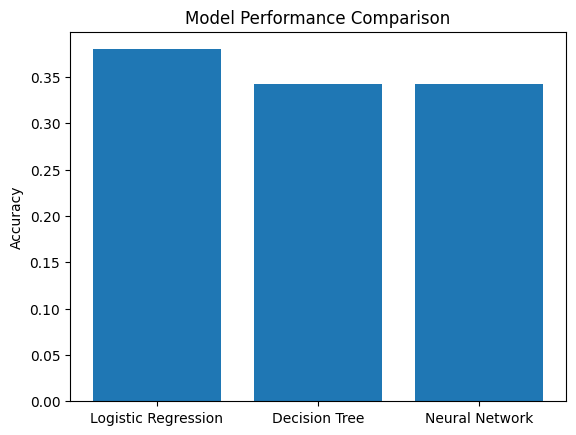

In [34]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Decision Tree", "Neural Network"]
scores = [accuracy_lr, accuracy_dt, accuracy_ann]

plt.bar(models, scores)
plt.ylabel("Accuracy")
plt.title("Model Performance Comparison")
plt.show()

In [35]:
sample = X_test.iloc[0:1]

prediction = model_lr.predict(sample)

print("Predicted Category:", prediction)
print("Actual Category:", y_test[0])

Predicted Category: [3]
Actual Category: 2


In [36]:
import pandas as pd

importance = model_dt.feature_importances_

feature_importance = pd.Series(importance, index=X.columns)

feature_importance.sort_values(ascending=False).head(10)

,0
absences,0.094418
health,0.088871
goout,0.066542
freetime,0.056505
age,0.045711
failures,0.038456
famrel,0.038427
studytime,0.036477
romantic_no,0.033383
Pstatus_T,0.031069


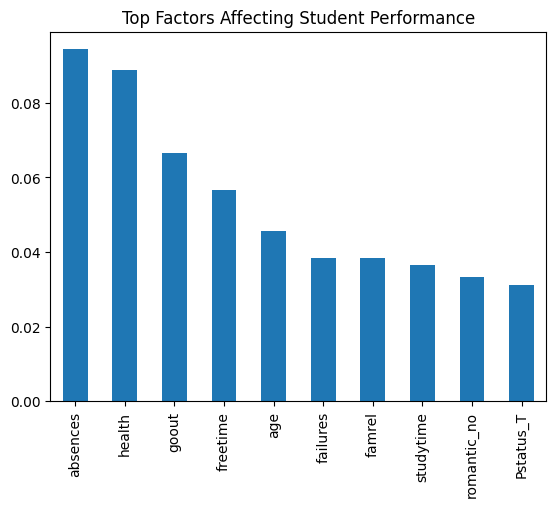

In [37]:
feature_importance.sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top Factors Affecting Student Performance")
plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
pip install numpy

Replace `numpy` with the name of the library you want to install. If you want to install a specific version, you can specify it like this:

```python
pip install library_name==1.2.3
```

If the library is not found in the default Python Package Index (PyPI), you might need to specify an extra index URL:

```python
pip install --extra-index-url https://example.com/pypi/project/ library_name
```

In [2]:
import pandas as pd